In [1]:
!pip install pyreadstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 80.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler # Import RandomOverSampler (ROSE)
from matplotlib import pyplot
import imblearn
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn import datasets
from sklearn.preprocessing import LabelBinarizer

In [3]:
df = pd.read_excel("/content/perfect_final_data_for_multilevel_analysis.xlsx")
df

,V001,V002,V012,V013,V024,V025,V106,V113,V130,V157,...,Number_of_children,Living_children,Age_of_husband,profession_of_husband,Birth_Interval,Drinking_water,Wealth_Status,Religion_status,BMI,Respondent_Age_first_birth
0,469,57,48,7,6,2,0,21,1,0,...,2,2,2,1,4,2,0,1,4,1
1,438,26,32,4,6,1,2,21,1,0,...,1,1,1,2,1,2,2,1,4,0
2,296,96,39,5,4,1,2,21,1,0,...,2,2,2,4,1,2,2,1,4,1
3,438,4,48,7,6,1,0,21,1,0,...,2,2,2,2,1,2,2,1,4,0
4,548,158,32,4,7,2,3,12,1,0,...,1,1,1,1,2,1,0,1,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8497,417,132,41,6,5,2,1,21,1,0,...,2,1,2,1,3,2,0,1,1,0
8498,190,11,43,6,3,1,0,11,1,0,...,1,1,1,3,3,1,1,1,1,1
8499,123,123,40,6,2,2,0,21,1,0,...,1,1,2,2,1,2,0,1,1,1
8500,581,64,30,4,7,2,1,21,2,0,...,2,2,1,2,2,2,0,0,1,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   V001                        8502 non-null   int64  
 1   V002                        8502 non-null   int64  
 2   V012                        8502 non-null   int64  
 3   V013                        8502 non-null   int64  
 4   V024                        8502 non-null   int64  
 5   V025                        8502 non-null   int64  
 6   V106                        8502 non-null   int64  
 7   V113                        8502 non-null   int64  
 8   V130                        8502 non-null   int64  
 9   V157                        8502 non-null   int64  
 10  V158                        8502 non-null   int64  
 11  V159                        8502 non-null   int64  
 12  V190                        8502 non-null   int64  
 13  V201                        8502 

In [5]:
df.drop(columns=['V001', 'V002', 'V012', 'V113', 'V130', 'V157', 'V158',
                 'V159', 'V190', 'V201', 'V212', 'V218', 'V221', 'V364', 'V445','V447', 'V501',
                 'V502', 'V701', 'V705', 'V730'], inplace=True)

In [6]:
df.head(5)

,V013,V024,V025,V106,V404,V714,BMI_fixed,Media_acccess,husband_education,contraceptive_use,Number_of_children,Living_children,Age_of_husband,profession_of_husband,Birth_Interval,Drinking_water,Wealth_Status,Religion_status,BMI,Respondent_Age_first_birth
0,7,6,2,0,0,0,46.90,0,0,0,2,2,2,1,4,2,0,1,4,1
1,4,6,1,2,0,1,46.74,1,2,0,1,1,1,2,1,2,2,1,4,0
2,5,4,1,2,0,0,45.28,1,3,1,2,2,2,4,1,2,2,1,4,1
3,7,6,1,0,0,0,45.21,1,2,0,2,2,2,2,1,2,2,1,4,0
4,4,7,2,3,0,0,45.09,0,1,0,1,1,1,1,2,1,0,1,4,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   V013                        8502 non-null   int64  
 1   V024                        8502 non-null   int64  
 2   V025                        8502 non-null   int64  
 3   V106                        8502 non-null   int64  
 4   V404                        8502 non-null   int64  
 5   V714                        8502 non-null   int64  
 6   BMI_fixed                   8502 non-null   float64
 7   Media_acccess               8502 non-null   int64  
 8   husband_education           8502 non-null   int64  
 9   contraceptive_use           8502 non-null   int64  
 10  Number_of_children          8502 non-null   int64  
 11  Living_children             8502 non-null   int64  
 12  Age_of_husband              8502 non-null   int64  
 13  profession_of_husband       8502 

In [8]:
df.drop(columns=['BMI_fixed'], inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   V013                        8502 non-null   int64
 1   V024                        8502 non-null   int64
 2   V025                        8502 non-null   int64
 3   V106                        8502 non-null   int64
 4   V404                        8502 non-null   int64
 5   V714                        8502 non-null   int64
 6   Media_acccess               8502 non-null   int64
 7   husband_education           8502 non-null   int64
 8   contraceptive_use           8502 non-null   int64
 9   Number_of_children          8502 non-null   int64
 10  Living_children             8502 non-null   int64
 11  Age_of_husband              8502 non-null   int64
 12  profession_of_husband       8502 non-null   int64
 13  Birth_Interval              8502 non-null   int64
 14  Drinking

In [10]:
# Robust Scaling (FT4)
from sklearn.preprocessing import RobustScaler  # import robust scaler
FT4 = RobustScaler()  # create the robust scaler
FT4_data = FT4.fit_transform(df)  # scale data using median and spread
FT4_df = pd.DataFrame(FT4_data, columns=df.columns)  # convert scaled data into a DataFrame
print(FT4_df.head())  # show the first few robust scaled rows

       V013  V024  V025  V106  V404  V714  Media_acccess  husband_education  \
0  1.000000  0.50   0.0  -2.0   0.0   0.0           -1.0               -1.0   
1  0.000000  0.50  -1.0   0.0   0.0   1.0            0.0                1.0   
2  0.333333  0.00  -1.0   0.0   0.0   0.0            0.0                2.0   
3  1.000000  0.50  -1.0  -2.0   0.0   0.0            0.0                1.0   
4  0.000000  0.75   0.0   1.0   0.0   0.0           -1.0                0.0   

   contraceptive_use  Number_of_children  Living_children  Age_of_husband  \
0               -1.0                 1.0              1.0             1.0   
1               -1.0                 0.0              0.0             0.0   
2                0.0                 1.0              1.0             1.0   
3               -1.0                 1.0              1.0             1.0   
4               -1.0                 0.0              0.0             0.0   

   profession_of_husband  Birth_Interval  Drinking_water  Weal

In [11]:
df.info()  # check the data types and missing values again

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   V013                        8502 non-null   int64
 1   V024                        8502 non-null   int64
 2   V025                        8502 non-null   int64
 3   V106                        8502 non-null   int64
 4   V404                        8502 non-null   int64
 5   V714                        8502 non-null   int64
 6   Media_acccess               8502 non-null   int64
 7   husband_education           8502 non-null   int64
 8   contraceptive_use           8502 non-null   int64
 9   Number_of_children          8502 non-null   int64
 10  Living_children             8502 non-null   int64
 11  Age_of_husband              8502 non-null   int64
 12  profession_of_husband       8502 non-null   int64
 13  Birth_Interval              8502 non-null   int64
 14  Drinking

In [12]:
# FT4_df.head()  # this would preview the robust scaled data
y = FT4_df.BMI  # use bmi1 as the target variable
x = FT4_df.drop('BMI', axis=1)  # use the other columns as features

In [13]:
y  # display the target column

,BMI
0,2.0
1,2.0
2,2.0
3,2.0
4,2.0
...,...
8497,-1.0
8498,-1.0
8499,-1.0
8500,-1.0


In [14]:
x  # display the feature columns

,V013,V024,V025,V106,V404,V714,Media_acccess,husband_education,contraceptive_use,Number_of_children,Living_children,Age_of_husband,profession_of_husband,Birth_Interval,Drinking_water,Wealth_Status,Religion_status,Respondent_Age_first_birth
0,1.000000,0.50,0.0,-2.0,0.0,0.0,-1.0,-1.0,-1.0,1.0,1.0,1.0,-0.333333,0.333333,0.0,-0.5,0.0,1.0
1,0.000000,0.50,-1.0,0.0,0.0,1.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.000000,-0.666667,0.0,0.5,0.0,0.0
2,0.333333,0.00,-1.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,1.0,0.666667,-0.666667,0.0,0.5,0.0,1.0
3,1.000000,0.50,-1.0,-2.0,0.0,0.0,0.0,1.0,-1.0,1.0,1.0,1.0,0.000000,-0.666667,0.0,0.5,0.0,0.0
4,0.000000,0.75,0.0,1.0,0.0,0.0,-1.0,0.0,-1.0,0.0,0.0,0.0,-0.333333,-0.333333,-1.0,-0.5,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8497,0.666667,0.25,0.0,-1.0,0.0,0.0,-1.0,-1.0,0.0,1.0,0.0,1.0,-0.333333,0.000000,0.0,-0.5,0.0,0.0
8498,0.666667,-0.25,-1.0,-2.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.333333,0.000000,-1.0,0.0,0.0,1.0
8499,0.666667,-0.50,0.0,-2.0,0.0,0.0,-1.0,-1.0,0.0,0.0,0.0,1.0,0.000000,-0.666667,0.0,-0.5,0.0,1.0
8500,0.000000,0.75,0.0,-1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.000000,-0.333333,0.0,-0.5,-1.0,1.0


In [15]:
y = LabelEncoder().fit_transform(y)  # change target labels into numbers
oversample = RandomOverSampler(random_state=101)  # create RandomOverSampler to balance classes
x, y = oversample.fit_resample(x, y)  # make class counts more balanced
counter = Counter(y)  # count samples in each class
for k, v in counter.items():  # loop through each class count
  per = v / len(y) * 100  # calculate class percentage
  print('class=%d, count=%d, percentage=%.3f%%' % (k, v, per))  # print class distribution

class=3, count=4469, percentage=25.000%
class=2, count=4469, percentage=25.000%
class=1, count=4469, percentage=25.000%
class=0, count=4469, percentage=25.000%


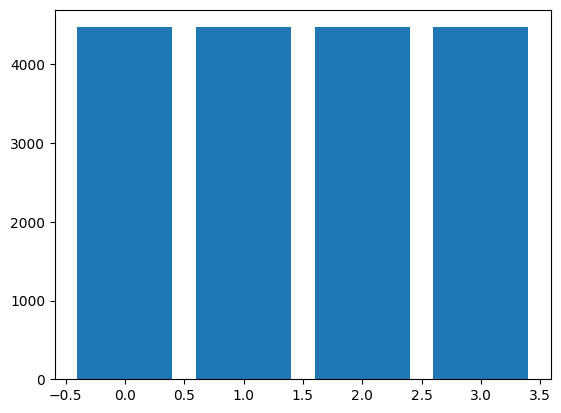

In [16]:
pyplot.bar(counter.keys(), counter.values())  # draw a bar chart for class counts
pyplot.show()  # show the chart

In [17]:
from sklearn.model_selection import train_test_split  # import the train-test split tool
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=101)  # split data into training and testing sets
x_train.head()  # preview the training features
x_train.shape  # check the training data shape

(12513, 18)

In [18]:
x_test.head()  # preview the testing features
x_test.shape  # check the testing data shape

(5363, 18)

In [19]:
# logistic regression
from sklearn.linear_model import LogisticRegression  # import logistic regression
Lr = LogisticRegression()  # create the model
Lr.fit(x_train, y_train)  # train the model on the training data

# Generate predictions for both test and training data
predictions = Lr.predict(x_test)  # predict labels for the test set
train_predictions = Lr.predict(x_train)  # predict labels for the training set

from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools

# Train performance
print("=== Training Performance ===")  # print training results heading
print(classification_report(y_train, train_predictions, digits=4))  # show training metrics
print(confusion_matrix(y_train, train_predictions))  # show training confusion matrix
# test performance
print("=== Test Performance ===")  # print test results heading
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = Lr.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities for ROC work

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # measure agreement between true and predicted labels

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(Lr, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

=== Training Performance ===
              precision    recall  f1-score   support

           0     0.4497    0.6163    0.5200      3120
           1     0.3099    0.1950    0.2394      3113
           2     0.3243    0.1880    0.2380      3112
           3     0.4329    0.6114    0.5069      3168

    accuracy                         0.4037     12513
   macro avg     0.3792    0.4027    0.3761     12513
weighted avg     0.3795    0.4037    0.3767     12513

[[1923  505  311  381]
 [1229  607  474  803]
 [ 666  508  585 1353]
 [ 458  339  434 1937]]
=== Test Performance ===
              precision    recall  f1-score   support

           0     0.4309    0.5893    0.4978      1349
           1     0.3170    0.1954    0.2418      1356
           2     0.3329    0.2012    0.2508      1357
           3     0.4157    0.5949    0.4894      1301

    accuracy                         0.3929      5363
   macro avg     0.3741    0.3952    0.3700      5363
weighted avg     0.3736    0.3929    0

In [20]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier  # import decision tree model
dtree = DecisionTreeClassifier()  # create the model
dtree.fit(x_train, y_train)  # train the model
predictions = dtree.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = dtree.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(dtree, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.8506    0.9748    0.9085      1349
           1     0.6979    0.4889    0.5750      1356
           2     0.7139    0.7060    0.7099      1357
           3     0.8492    0.9954    0.9165      1301

    accuracy                         0.7889      5363
   macro avg     0.7779    0.7913    0.7775      5363
weighted avg     0.7770    0.7889    0.7759      5363

[[1315   16   13    5]
 [ 187  663  369  137]
 [  44  267  958   88]
 [   0    4    2 1295]]
Cross Validation Scores are [0.82214765 0.83892617 0.81823266 0.82494407 0.83724832 0.8238255
 0.82988248 0.82988248 0.81701175 0.83603805 0.82774049 0.82550336
 0.83836689 0.82606264 0.8238255  0.83501119 0.8276441  0.81869054
 0.83491886 0.81141578 0.82550336 0.8098434  0.8310962  0.83277405
 0.82774049 0.82494407 0.82316732 0.82260772 0.81645215 0.81421377]
Average Cross Validation score :0.8258553677295672


In [21]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier  # import random forest model
rfc = RandomForestClassifier(n_estimators=100)  # create the model with 100 trees
rfc.fit(x_train, y_train)  # train the model
predictions = rfc.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = rfc.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(rfc, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.8918    0.9711    0.9297      1349
           1     0.7231    0.6047    0.6586      1356
           2     0.7337    0.7288    0.7312      1357
           3     0.9164    0.9946    0.9539      1301

    accuracy                         0.8229      5363
   macro avg     0.8162    0.8248    0.8184      5363
weighted avg     0.8151    0.8229    0.8168      5363

[[1310   25   14    0]
 [ 136  820  339   61]
 [  23  288  989   57]
 [   0    1    6 1294]]
Cross Validation Scores are [0.84395973 0.88255034 0.86577181 0.86073826 0.86017897 0.8696868
 0.8651371  0.86289871 0.86010073 0.87409065 0.86353468 0.86073826
 0.87416107 0.86017897 0.87192394 0.86129754 0.86066032 0.8645775
 0.87185227 0.86177952 0.85682327 0.84731544 0.86185682 0.86856823
 0.86521253 0.87472036 0.86905428 0.86233912 0.86010073 0.86177952]
Average Cross Validation score :0.8641195818503594


In [22]:
# K- nearest neighbor
from sklearn.neighbors import KNeighborsClassifier  # import KNN model
KN = KNeighborsClassifier()  # create the model
KN.fit(x_train, y_train)  # train the model
predictions = KN.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = KN.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(KN, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.6393    0.8933    0.7452      1349
           1     0.4783    0.2765    0.3505      1356
           2     0.5570    0.4215    0.4799      1357
           3     0.6797    0.8709    0.7635      1301

    accuracy                         0.6125      5363
   macro avg     0.5885    0.6155    0.5848      5363
weighted avg     0.5875    0.6125    0.5827      5363

[[1205   74   52   18]
 [ 416  375  321  244]
 [ 229  284  572  272]
 [  35   51   82 1133]]
Cross Validation Scores are [0.67561521 0.66946309 0.67561521 0.66946309 0.66387025 0.67729306
 0.67823167 0.67879127 0.67151651 0.68382764 0.66778523 0.6901566
 0.66610738 0.66442953 0.68680089 0.6689038  0.68102966 0.67767208
 0.69501959 0.66032457 0.6689038  0.68791946 0.6761745  0.67897092
 0.66666667 0.67729306 0.66815893 0.6726357  0.68606603 0.67991046]
Average Cross Validation score :0.6754871958260148


In [23]:
# GaussianNB
from sklearn.naive_bayes import GaussianNB  # import Gaussian Naive Bayes model
NB = GaussianNB()  # create the model
NB.fit(x_train, y_train)  # train the model
predictions = NB.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = NB.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(NB, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.4197    0.6219    0.5012      1349
           1     0.3234    0.1755    0.2275      1356
           2     0.3300    0.1680    0.2227      1357
           3     0.4171    0.6211    0.4991      1301

    accuracy                         0.3940      5363
   macro avg     0.3725    0.3966    0.3626      5363
weighted avg     0.3720    0.3940    0.3610      5363

[[839 189 127 194]
 [586 238 188 344]
 [349 189 228 591]
 [225 120 148 808]]
Cross Validation Scores are [0.41275168 0.38422819 0.38310962 0.39821029 0.41163311 0.41163311
 0.423615   0.40570789 0.38668159 0.42081701 0.4082774  0.39541387
 0.41107383 0.40771812 0.40212528 0.3942953  0.42137661 0.39115837
 0.38891998 0.40123111 0.42841163 0.3942953  0.40883669 0.40883669
 0.39709172 0.40548098 0.39507555 0.39955232 0.40123111 0.38947957]
Average Cross Validation score :0.4029422976530723


In [24]:
# support vector machine
from sklearn.svm import LinearSVC  # import linear SVM model
classifier = LinearSVC()  # create the model
classifier.fit(x_train, y_train)  # train the model
y_predict = classifier.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, y_predict, digits=4))  # show test metrics
print(confusion_matrix(y_test, y_predict))  # show test confusion matrix
y_score = classifier.fit(x_train, y_train).decision_function(x_test)  # get decision scores

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, y_predict)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(classifier, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.4091    0.6709    0.5083      1349
           1     0.3109    0.0988    0.1500      1356
           2     0.3497    0.1415    0.2015      1357
           3     0.3906    0.6518    0.4885      1301

    accuracy                         0.3877      5363
   macro avg     0.3651    0.3907    0.3371      5363
weighted avg     0.3648    0.3877    0.3352      5363

[[905 126  80 238]
 [647 134 156 419]
 [387 112 192 666]
 [273  59 121 848]]
Cross Validation Scores are [0.39932886 0.38534676 0.38422819 0.38422819 0.40436242 0.41219239
 0.41130386 0.40962507 0.36989368 0.39955232 0.39653244 0.40212528
 0.40883669 0.40436242 0.38814318 0.39205817 0.40850588 0.39059877
 0.37604924 0.39843313 0.42058166 0.39709172 0.39876957 0.39709172
 0.38255034 0.38310962 0.38668159 0.40235031 0.39843313 0.39003917]
Average Cross Validation score :0.3960801913897162


In [25]:
# AdaBoostClassifier
from sklearn.ensemble import AdaBoostClassifier  # import AdaBoost model
abc = AdaBoostClassifier(n_estimators=50, learning_rate=1)  # create the model
model = abc.fit(x_train, y_train)  # train the model
y_pred = model.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, y_pred, digits=4))  # show test metrics
print(confusion_matrix(y_test, y_pred))  # show test confusion matrix
y_score = abc.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(abc, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.4435    0.5997    0.5099      1349
           1     0.3212    0.1563    0.2103      1356
           2     0.3133    0.2454    0.2752      1357
           3     0.4009    0.5596    0.4671      1301

    accuracy                         0.3882      5363
   macro avg     0.3697    0.3903    0.3656      5363
weighted avg     0.3693    0.3882    0.3644      5363

[[809 161 187 192]
 [550 212 251 343]
 [308 163 333 553]
 [157 124 292 728]]
Cross Validation Scores are [0.39373602 0.37360179 0.38814318 0.37863535 0.39932886 0.41387025
 0.43480694 0.39787353 0.39003917 0.39619474 0.39317673 0.39261745
 0.41442953 0.38310962 0.39485459 0.39988814 0.4045887  0.39115837
 0.3850028  0.38276441 0.42170022 0.41219239 0.39261745 0.37695749
 0.38087248 0.38926174 0.39115837 0.38947957 0.39787353 0.36877448]
Average Cross Validation score :0.3942902631358219


In [26]:
# GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingClassifier  # import gradient boosting model
GB = GradientBoostingClassifier()  # create the model
model = GB.fit(x_train, y_train)  # train the model
predictions = model.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = GB.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(GB, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.5112    0.6234    0.5618      1349
           1     0.3587    0.2537    0.2972      1356
           2     0.4124    0.3088    0.3531      1357
           3     0.4796    0.6426    0.5493      1301

    accuracy                         0.4550      5363
   macro avg     0.4405    0.4571    0.4403      5363
weighted avg     0.4400    0.4550    0.4391      5363

[[841 218 137 153]
 [449 344 269 294]
 [223 255 419 460]
 [132 142 191 836]]
Cross Validation Scores are [0.47818792 0.45190157 0.45637584 0.46029083 0.46196868 0.46868009
 0.46670397 0.47789591 0.44711807 0.46334639 0.47762864 0.46923937
 0.47818792 0.4614094  0.4541387  0.4614094  0.4806939  0.45775042
 0.45327364 0.46894236 0.4787472  0.46252796 0.46868009 0.47259508
 0.46029083 0.46252796 0.4622272  0.4801343  0.4812535  0.47062115]
Average Cross Validation score :0.4664916100079829


In [27]:
# XGBoost
from numpy import loadtxt  # import loadtxt from NumPy
from xgboost import XGBClassifier  # import XGBoost model
XGB = XGBClassifier()  # create the model
model = XGB.fit(x_train, y_train)  # train the model
predictions = model.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = XGB.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(XGB, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.7836    0.9155    0.8444      1349
           1     0.6143    0.4322    0.5074      1356
           2     0.6340    0.5822    0.6070      1357
           3     0.7587    0.9254    0.8338      1301

    accuracy                         0.7114      5363
   macro avg     0.6976    0.7138    0.6981      5363
weighted avg     0.6969    0.7114    0.6965      5363

[[1235   51   43   20]
 [ 242  586  357  171]
 [  92  283  790  192]
 [   7   34   56 1204]]
Cross Validation Scores are [0.73769575 0.74888143 0.72651007 0.72427293 0.72035794 0.73825503
 0.73587017 0.72915501 0.71964186 0.75825406 0.73154362 0.74888143
 0.7253915  0.72706935 0.73266219 0.73825503 0.72971461 0.72188025
 0.72859541 0.73363179 0.72986577 0.73657718 0.73489933 0.73489933
 0.75279642 0.73825503 0.72299944 0.73642977 0.74314494 0.72299944]
Average Cross Validation score :0.7336462027727805


In [28]:
# Bagging
from sklearn.ensemble import BaggingClassifier
BC=BaggingClassifier()
model=BC.fit(x_train, y_train)
predictions = model.predict(x_test)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,predictions,digits=4))
print(confusion_matrix(y_test,predictions))
y_score = BC.fit(x_train, y_train).predict_proba(x_test)

from sklearn.metrics import cohen_kappa_score
cohen_kappa_score(y_test,predictions)

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import  cross_val_score,KFold
kf = RepeatedStratifiedKFold(n_splits = 10, n_repeats=3, random_state=1)
scores = cross_val_score(BC, x, y, cv = kf)
print("Cross Validation Scores are {}".format(scores))
print("Average Cross Validation score :{}".format(scores.mean()))

              precision    recall  f1-score   support

           0     0.8185    0.9696    0.8877      1349
           1     0.6993    0.5162    0.5940      1356
           2     0.7235    0.6942    0.7085      1357
           3     0.8851    0.9946    0.9367      1301

    accuracy                         0.7913      5363
   macro avg     0.7816    0.7937    0.7817      5363
weighted avg     0.7805    0.7913    0.7800      5363

[[1308   24   13    4]
 [ 222  700  341   93]
 [  68  276  942   71]
 [   0    1    6 1294]]
Cross Validation Scores are [0.84340045 0.84899329 0.83053691 0.83948546 0.83780761 0.83557047
 0.83268047 0.8455512  0.82988248 0.83995523 0.84004474 0.8344519
 0.83221477 0.83612975 0.848434   0.83389262 0.82876329 0.83715725
 0.83324007 0.83547846 0.83277405 0.82214765 0.83165548 0.83836689
 0.82885906 0.83836689 0.82932289 0.84219362 0.83827644 0.83715725]
Average Cross Validation score :0.8360930212275498
